In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import shap
import lime
import lime.lime_tabular
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
crop = pd.read_csv("Crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
crop.shape

(2200, 8)

In [4]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
crop.duplicated().sum()

0

In [7]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
crop.corr()

C:\Users\User\AppData\Local\Temp\ipykernel_16692\1215994360.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  crop.corr()


,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


C:\Users\User\AppData\Local\Temp\ipykernel_16692\1220241213.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(crop.corr(), annot=True, cbar=True)


<Axes: >

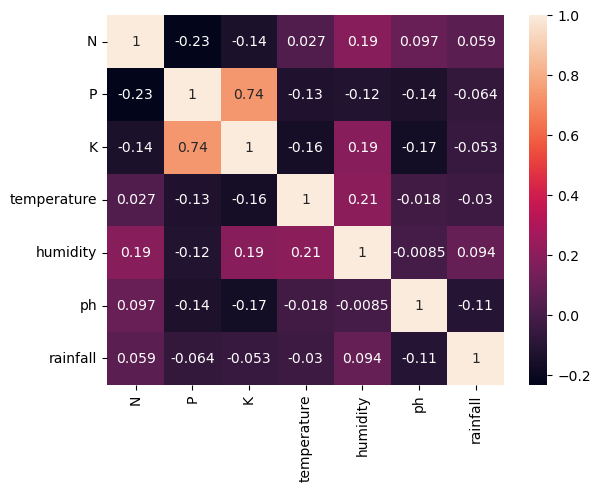

In [9]:
sns.heatmap(crop.corr(), annot=True, cbar=True)

In [10]:
crop.label.value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

<Axes: xlabel='P', ylabel='Count'>

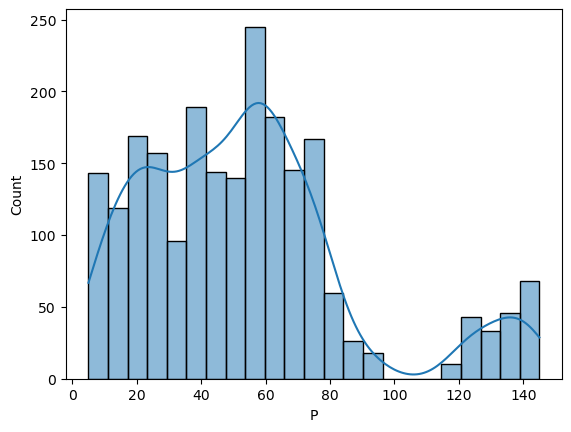

In [11]:
import matplotlib.pyplot as plt
sns.histplot(crop['P'],kde=True)

<Axes: xlabel='N', ylabel='Count'>

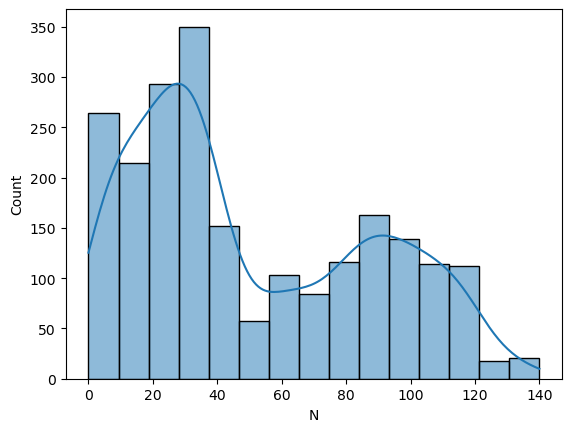

In [12]:
import matplotlib.pyplot as plt
sns.histplot(crop['N'],kde=True)

In [13]:
crop_dict = {
    'rice': 0,
    'maize': 1,
    'jute': 2,
    'cotton': 3,
    'coconut': 4,
    'papaya': 5,
    'orange': 6,
    'apple': 7,
    'muskmelon': 8,
    'watermelon': 9,
    'grapes': 10,
    'mango': 11,
    'banana': 12,
    'pomegranate': 13,
    'lentil': 14,
    'blackgram': 15,
    'mungbean': 16,
    'mothbeans': 17,
    'pigeonpeas': 18,
    'kidneybeans': 19,
    'chickpea': 20,
    'coffee': 21
}

crop['label'] = crop['label'].map(crop_dict)

reverse_crop_dict = {v: k for k, v in crop_dict.items()}


In [14]:
def count_outliers(crop):
    outlier_counts = {}
    for col in crop.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = crop[col].quantile(0.25)
        Q3 = crop[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        count = crop[(crop[col] < lower) | (crop[col] > upper)].shape[0]
        outlier_counts[col] = count
    return outlier_counts

In [15]:
outlier_sums = count_outliers(crop)
for col, count in outlier_sums.items():
    print(f"{col}: {count} outliers")

N: 0 outliers
P: 138 outliers
K: 200 outliers
temperature: 86 outliers
humidity: 30 outliers
ph: 57 outliers
rainfall: 100 outliers
label: 0 outliers


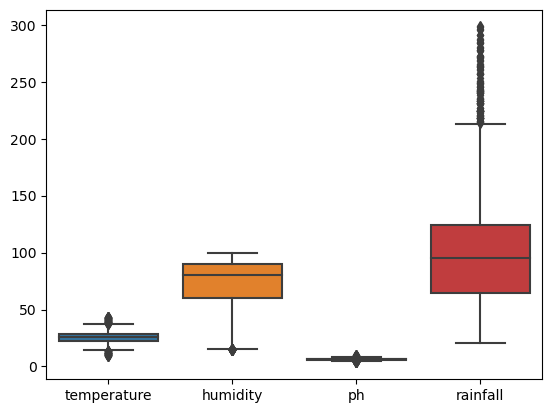

In [16]:

sns.boxplot(data=crop[['temperature', 'humidity', 'ph', 'rainfall']])
plt.show()


In [17]:
def impute_outliers_with_median(crop, col):
    Q1 = crop[col].quantile(0.25)
    Q3 = crop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = crop[col].median()
    crop.loc[(crop[col] < lower) | (crop[col] > upper), col] = median
    return crop

def clip_outliers_iqr(crop, columns):
    for col in columns:
        Q1 = crop[col].quantile(0.25)
        Q3 = crop[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        crop[col] = crop[col].clip(lower=lower, upper=upper)
    return crop

# Apply to your dataset
crop= impute_outliers_with_median(crop, 'P')
crop= impute_outliers_with_median(crop, 'K')

crop= clip_outliers_iqr(crop, ['temperature', 'humidity', 'ph', 'rainfall'])

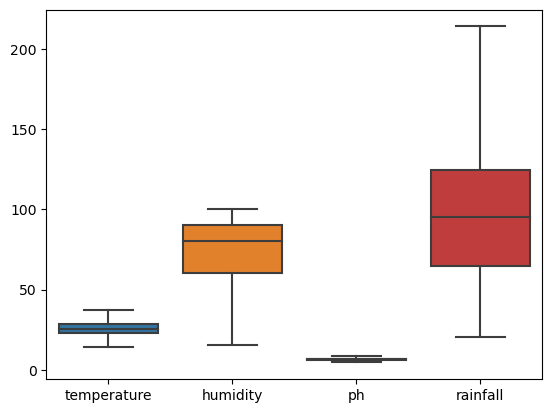

In [18]:

sns.boxplot(data=crop[['temperature', 'humidity', 'ph', 'rainfall']])
plt.show()


In [19]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,0
1,85,58,41,21.770462,80.319644,7.038096,213.841241,0
2,60,55,44,23.004459,82.320763,7.840207,213.841241,0
3,74,35,40,26.491096,80.158363,6.980401,213.841241,0
4,78,42,42,20.130175,81.604873,7.628473,213.841241,0


In [20]:
crop.label.unique()

array([ 0,  1, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,
        5,  4,  3,  2, 21], dtype=int64)

In [21]:
x=crop.drop('label',axis=1)
y=crop['label']

In [22]:
x.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,213.841241
2,60,55,44,23.004459,82.320763,7.840207,213.841241
3,74,35,40,26.491096,80.158363,6.980401,213.841241
4,78,42,42,20.130175,81.604873,7.628473,213.841241


In [23]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
x_train.shape

(1760, 7)

In [26]:
# from sklearn.preprocessing import MinMaxScaler
# mx=MinMaxScaler()
# x_train=mx.fit_transform(x_train)
# x_test=mx.transform(x_test)

In [27]:
x_train

,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,32,14.080956,80.066340,6.361141,71.400430


In [28]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [29]:

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [30]:
models = {
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'ExtraTreeClassifier': ExtraTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'XGBClassifier': XGBClassifier(),
    'LGBMClassifier': LGBMClassifier(max_depth=6,
    num_leaves=31,
    min_split_gain=0.1,
    min_child_samples=20,
    verbose=-1)
}

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
import pandas as pd

warnings.filterwarnings("ignore")

metrics_data = []

for name, model in models.items():
    model.fit(x_train, y_train) 
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    
    metrics_data.append([name, accuracy, precision, recall, f1])

metrics_df = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print(metrics_df)


                        Model  Accuracy  Precision    Recall  F1-Score
0          LogisticRegression  0.965909   0.967205  0.965909  0.965833
1                         SVC  0.975000   0.977001  0.975000  0.975126
2        KNeighborsClassifier  0.968182   0.973326  0.968182  0.968078
3      DecisionTreeClassifier  0.977273   0.978036  0.977273  0.977250
4         ExtraTreeClassifier  0.886364   0.898971  0.886364  0.887302
5      RandomForestClassifier  0.995455   0.995818  0.995455  0.995423
6  GradientBoostingClassifier  0.981818   0.983703  0.981818  0.981631
7          AdaBoostClassifier  0.168182   0.975729  0.168182  0.144599
8               XGBClassifier  0.988636   0.989269  0.988636  0.988613
9              LGBMClassifier  0.984091   0.984692  0.984091  0.984055


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(100, 500),        # Number of trees
    'max_depth': [None, 10, 20, 30, 40, 50],  # Control overfitting
    'min_samples_split': randint(2, 10),      # Split condition
    'min_samples_leaf': randint(1, 5),        # Leaf size
    'max_features': ['sqrt', 'log2'],         # Feature sampling
    'bootstrap': [True, False]                # Use bagging or not
}
rf=RandomForestClassifier()
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,              # Try 30 random combinations
    cv=5,                   # 5-fold cross-validation
    scoring='accuracy',    
    n_jobs=-1,
    verbose=2,
    random_state=42
)
random_search.fit(x_train, y_train)  

print("Best Parameters:", random_search.best_params_)     
print("Best CV Score:", random_search.best_score_)        



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'bootstrap': False, 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 376}
Best CV Score: 0.9954545454545455


In [33]:

y_pred_tuned=random_search.predict(x_test)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       1.00      1.00      1.00        21
           2       0.92      1.00      0.96        23
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        23
           8       1.00      1.00      1.00        17
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        14
          11       1.00      1.00      1.00        19
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        23
          14       0.92      1.00      0.96        11
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        19
          17       1.00    

In [34]:
crop.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [35]:
def recommendation(N, P, K, temperature, humidity, ph, rainfall):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    #mx_features = mx.transform(features)  
    sc_mx_features = sc.transform(features)
    prediction = random_search.predict(sc_mx_features)
    class_index = prediction.item()
    decoded_crop = reverse_crop_dict[class_index]
#     print("Input features:", features)
#     print("After mx scaling:", mx_features)
#     print("After sc scaling:", sc_mx_features)
    print("Prediction:", prediction)

    return decoded_crop

In [36]:
crop.head(500)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,0
1,85,58,41,21.770462,80.319644,7.038096,213.841241,0
2,60,55,44,23.004459,82.320763,7.840207,213.841241,0
3,74,35,40,26.491096,80.158363,6.980401,213.841241,0
4,78,42,42,20.130175,81.604873,7.628473,213.841241,0
...,...,...,...,...,...,...,...,...
495,35,71,17,29.892866,66.353751,6.931925,198.140300,18
496,11,72,22,29.377356,44.822946,6.842744,172.401680,18
497,20,60,22,29.650529,42.898332,6.876573,186.922605,18
498,10,71,18,19.542849,66.347773,6.151029,173.110698,18


In [37]:
N=120
P=80
K=200
temperature=29.874845
humidity=66.792613
ph=6.718725
rainfall=200
predict=recommendation(82,22,45,26.22338015,85.34866045,6.512196212,54.60159289)
predict

Prediction: [9]


'watermelon'

In [38]:
import pickle

# Save model
with open("model2.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save scalers
with open("scaler2.pkl", "wb") as f:
    pickle.dump(sc, f)

# with open("minmax2.pkl", "wb") as f:
#     pickle.dump(mx, f)

# Save label mappings
with open("crop_dict2.pkl", "wb") as f:
    pickle.dump((crop_dict, reverse_crop_dict), f)



In [39]:
class_names = [crop for crop, label in sorted(crop_dict.items(), key=lambda x: x[1])]

In [40]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt


In [41]:
from sklearn.model_selection import train_test_split
x_train_orig, x_test_orig, y_train_orig, y_test_orig = train_test_split(
    x, y, test_size=0.2, random_state=42
)

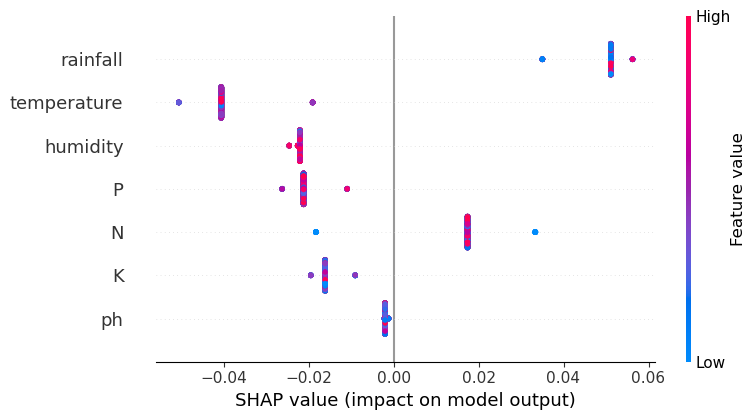

In [42]:
explainer = shap.TreeExplainer(random_search.best_estimator_)
shap_values = explainer.shap_values(x_train_orig)  

# Example: plot SHAP summary for class 0
shap.summary_plot(shap_values[:, :, 0], x_train_orig, feature_names=x_train_orig.columns)


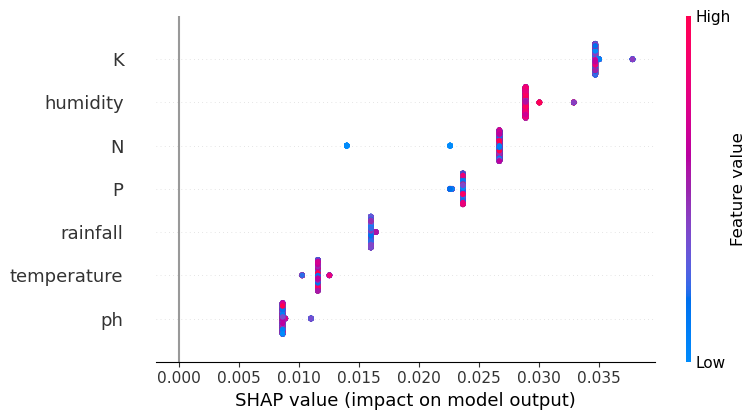

In [43]:
import numpy as np

mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2)) 
shap.summary_plot(np.mean(np.abs(shap_values), axis=2), x_train_orig)

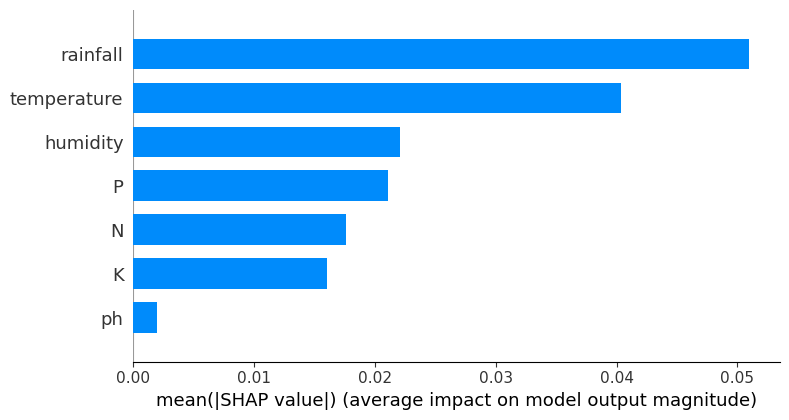

In [44]:
# Bar plot for class 0
shap.summary_plot(shap_values[:, :, 0], x_train_orig, feature_names=x_train_orig.columns, plot_type="bar")

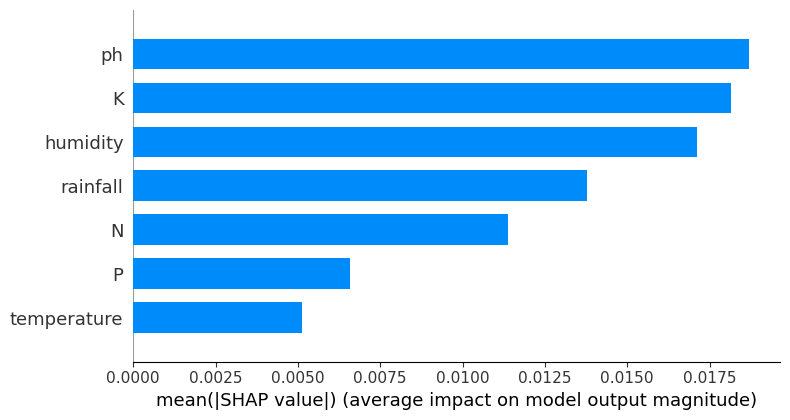

In [45]:
shap.summary_plot(shap_values[:, :, 17], x_train_orig, feature_names=x_train_orig.columns, plot_type="bar")

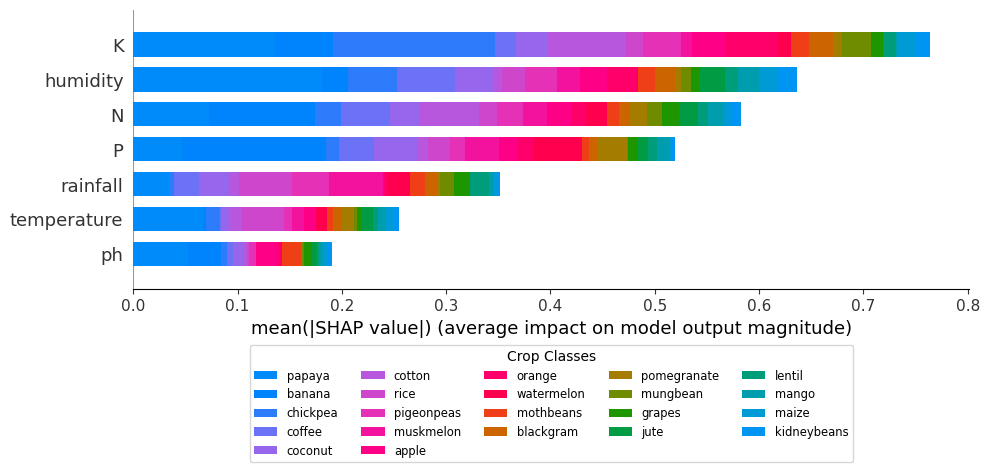

In [46]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    x_train_orig,
    plot_type="bar",
    class_names=class_names,
    show=False
)


plt.gcf().set_size_inches(10, 5)  

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  
    ncol=5,
    fontsize='small',
    title="Crop Classes"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  
plt.show()

In [47]:
import lime
import lime.lime_tabular

In [48]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=x.values,       
    feature_names=x_train_orig.columns.tolist(),   
    class_names=class_names,   
    mode='classification'
)


In [50]:
from lime.lime_tabular import LimeTabularExplainer

reverse_crop_dict = {v: k for k, v in crop_dict.items()}
class_names = [reverse_crop_dict[i] for i in sorted(reverse_crop_dict)]


def scaled_predict_fn(x):
    return random_search.predict_proba(sc.transform(x))

explainer = LimeTabularExplainer(
    training_data=x_train_orig.values,
    feature_names=x_train_orig.columns.tolist(),
    class_names=class_names,
    mode='classification'
)

i = 3

sample = x_test[i].reshape(1, -1)         
sample_unscaled = x_test_orig.iloc[i]      

predicted_class_index = random_search.predict(sample)[0]
actual_class_index = y_test.iloc[i]

predicted_crop = reverse_crop_dict[predicted_class_index]
actual_crop = reverse_crop_dict[actual_class_index]

print(f" Predicted Crop: {predicted_crop}")
print(f" Actual Crop: {actual_crop}")

exp = explainer.explain_instance(
    data_row=sample_unscaled,
    predict_fn=scaled_predict_fn,
    labels=[predicted_class_index]
)

print(f"\n---  Explanation for Class: {predicted_crop} ---")
exp.show_in_notebook(show_table=True, show_all=False, labels=[predicted_class_index])


 Predicted Crop: papaya
 Actual Crop: papaya

---  Explanation for Class: papaya ---


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import shap


N = float(input("Enter Nitrogen (N) level: "))
P = float(input("Enter Phosphorus (P) level: "))
K = float(input("Enter Potassium (K) level: "))
temperature = float(input("Enter Temperature (°C): "))
humidity = float(input("Enter Humidity (%): "))
ph = float(input("Enter Soil pH: "))
rainfall = float(input("Enter Rainfall (mm): "))


result = recommendation(N, P, K, temperature, humidity, ph, rainfall)
print(f"\n Predicted Crop: {result}")
predicted_class_index = crop_dict[result]

user_input = {
    "N": N,
    "P": P,
    "K": K,
    "temperature": temperature,
    "humidity": humidity,
    "ph": ph,
    "rainfall": rainfall
}
user_df = pd.DataFrame([user_input])

def scaled_predict_fn(x):
    #mx_scaled = mx.transform(x)
    sc_scaled = sc.transform(x)
    return random_search.predict_proba(sc_scaled)

lime_explainer = LimeTabularExplainer(
    training_data=x_train_orig.values,
    feature_names=list(user_input.keys()),
    class_names=[reverse_crop_dict[i] for i in sorted(reverse_crop_dict)],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    data_row=user_df.iloc[0],
    predict_fn=scaled_predict_fn,
    labels=[predicted_class_index]
)


lime_exp.show_in_notebook(show_table=True, show_all=False, labels=[predicted_class_index])




def explain_lime_textually(exp, label_index, crop_name, top_n=3):
    
    print(f"\nExplanation for why the model recommended: {crop_name.upper()}\n")
    
    lime_weights = exp.as_list(label=label_index)
    
    for feature, weight in lime_weights[:top_n]:
        direction = "positively influences" if weight > 0 else "negatively influences"
        print(f"- {feature}: This {direction} the recommendation for {crop_name.lower()} (impact score: {weight:.4f})")
    
    print("\nNote: Consider reviewing features with negative impact scores to improve decision confidence.\n")
explain_lime_textually(lime_exp, predicted_class_index, result)



Enter Nitrogen (N) level: 90
Enter Phosphorus (P) level: 43
Enter Potassium (K) level: 45
Enter Temperature (°C): 25
Enter Humidity (%): 80
Enter Soil pH: 6
Enter Rainfall (mm): 220
Prediction: [0]

 Predicted Crop: rice



Explanation for why the model recommended: RICE

- rainfall > 122.48: This positively influences the recommendation for rice (impact score: 0.0222)
- N > 85.00: This positively influences the recommendation for rice (impact score: 0.0177)
- K > 43.00: This positively influences the recommendation for rice (impact score: 0.0132)

Note: Consider reviewing features with negative impact scores to improve decision confidence.

